# Phase 3 & 4 Completion Notebook
## Hyperparameter Tuning | SIN Variant Comparison | Error Analysis

## Setup

In [1]:
!git clone https://github.com/rgeirhos/texture-vs-shape.git 2>/dev/null || echo 'Repo already exists'
%cd texture-vs-shape
!pip install torch torchvision matplotlib pandas seaborn -q


/kaggle/working/texture-vs-shape


In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import re
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, 'models')
sys.path.insert(0, 'code')
import probabilities_to_decision

mapping = probabilities_to_decision.ImageNetProbabilitiesTo16ClassesMapping()
STIMULI_DIR = 'stimuli/style-transfer-preprocessed-512'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## Helper: Shape Bias Computation
Reusable function used in all experiments.

In [3]:
def compute_shape_bias(model, transform, stimuli_dir=STIMULI_DIR, device=device):
    """
    Runs model on all cue-conflict stimuli.
    Returns: (shape_bias_percent, full_results_dataframe)
    """
    model.eval().to(device)
    results = []
    for category in os.listdir(stimuli_dir):
        cat_path = os.path.join(stimuli_dir, category)
        if not os.path.isdir(cat_path):
            continue
        for img_name in os.listdir(cat_path):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            name = re.sub(r'\.(png|jpg|jpeg)$', '', img_name, flags=re.IGNORECASE)
            parts = name.split('-')
            if len(parts) < 2:
                continue
            shape_cat   = re.sub(r'\d+', '', parts[0])
            texture_cat = re.sub(r'\d+', '', parts[1])
            img = Image.open(os.path.join(cat_path, img_name)).convert('RGB')
            inp = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(inp)
            probs    = torch.softmax(out, dim=1).squeeze().cpu().numpy()
            decision = mapping.probabilities_to_decision(probs)
            results.append({'shape': shape_cat, 'texture': texture_cat, 'decision': decision})

    df = pd.DataFrame(results)
    df_conflict = df[df['shape'] != df['texture']]
    cs = (df_conflict['decision'] == df_conflict['shape']).sum()
    ct = (df_conflict['decision'] == df_conflict['texture']).sum()
    sb = round(float(cs / (cs + ct) * 100), 2) if (cs + ct) > 0 else 0.0
    return sb, df

BASE_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print('Helper ready.')


Helper ready.


---
# Phase 3 - Hyperparameter Tuning
## 3A. Input Resolution Sweep

Testing how input resolution affects shape bias in standard ResNet-50.
Resolutions tested: **128, 192, 224 (default), 320, 384**

In [4]:
resnet50 = models.resnet50(weights='IMAGENET1K_V1').to(device)
resnet50.eval()

resolution_results = {}
resolutions = [128, 192, 224, 320, 384]

for res in resolutions:
    transform = transforms.Compose([
        transforms.Resize(int(res * 256 / 224)),
        transforms.CenterCrop(res),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    sb, _ = compute_shape_bias(resnet50, transform)
    resolution_results[res] = sb
    print(f'Resolution {res}x{res}: Shape Bias = {sb:.2f}%')

print('\nResolution sweep complete.')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


Resolution 128x128: Shape Bias = 40.09%
Resolution 192x192: Shape Bias = 26.86%
Resolution 224x224: Shape Bias = 22.21%
Resolution 320x320: Shape Bias = 14.72%
Resolution 384x384: Shape Bias = 13.48%

Resolution sweep complete.


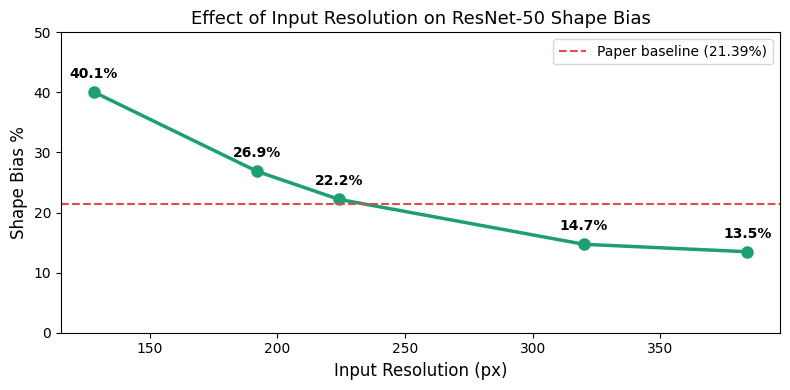

Saved: resolution_sweep.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(resolution_results.keys()), list(resolution_results.values()),
        marker='o', linewidth=2.5, color='#1D9E75', markersize=8)
ax.axhline(y=21.39, color='#E24B4A', linestyle='--', linewidth=1.5,
           label='Paper baseline (21.39%)')
for x_val, y_val in resolution_results.items():
    ax.annotate(f'{y_val:.1f}%', (x_val, y_val), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Input Resolution (px)', fontsize=12)
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('Effect of Input Resolution on ResNet-50 Shape Bias', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('resolution_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: resolution_sweep.png')


## 3B. Test-Time Augmentation Effects

Testing how different preprocessing augmentations shift the shape bias score at inference time.
Variants: **Baseline, Horizontal Flip, Color Jitter, Grayscale, Random Crop**

In [6]:
augmentation_variants = {
    'Baseline': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Horiz Flip': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Color Jitter': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Grayscale': transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Random Crop': transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

augmentation_results = {}
for aug_name, aug_transform in augmentation_variants.items():
    sb, _ = compute_shape_bias(resnet50, aug_transform)
    augmentation_results[aug_name] = sb
    print(f'{aug_name:<20}: Shape Bias = {sb:.2f}%')

print('\nAugmentation sweep complete.')


Baseline            : Shape Bias = 22.21%
Horiz Flip          : Shape Bias = 22.04%
Color Jitter        : Shape Bias = 29.49%
Grayscale           : Shape Bias = 37.27%
Random Crop         : Shape Bias = 19.63%

Augmentation sweep complete.


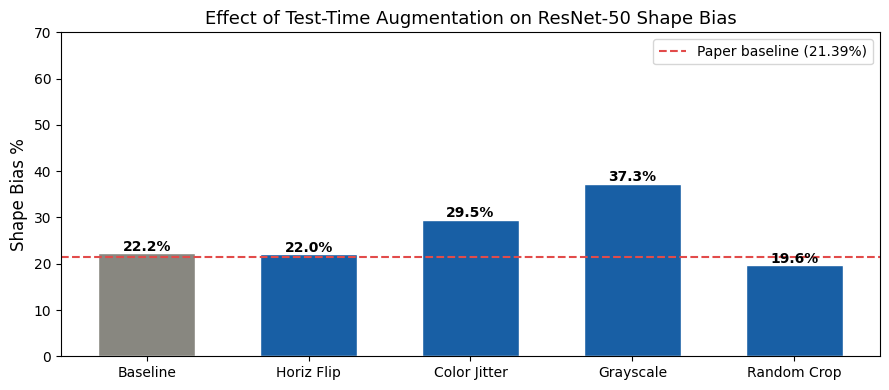

Saved: augmentation_effects.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#888780' if k == 'Baseline' else '#185FA5' for k in augmentation_results]
bars = ax.bar(list(augmentation_results.keys()), list(augmentation_results.values()),
              color=colors, edgecolor='white', width=0.6)
ax.axhline(y=21.39, color='#E24B4A', linestyle='--', linewidth=1.5,
           label='Paper baseline (21.39%)')
for bar, val in zip(bars, augmentation_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('Effect of Test-Time Augmentation on ResNet-50 Shape Bias', fontsize=13)
ax.set_ylim(0, 70)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('augmentation_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmentation_effects.png')


## 3C. Full Shape Bias for SIN-Trained Variants (Extension)


In [8]:
from load_pretrained_models import load_model

model_A = load_model('resnet50_trained_on_SIN')
model_B = load_model('resnet50_trained_on_SIN_and_IN')
model_C = load_model('resnet50_trained_on_SIN_and_IN_then_finetuned_on_IN')

sin_variants = {
    'ResNet-50 (IN only)':          resnet50,
    'ResNet-50 (SIN only)':         model_A,
    'ResNet-50 (SIN+IN)':           model_B,
    'ResNet-50 (SIN+IN finetuned)': model_C,
}

paper_sin = {
    'ResNet-50 (IN only)':          21.39,
    'ResNet-50 (SIN only)':         81.37,
    'ResNet-50 (SIN+IN)':           51.39,
    'ResNet-50 (SIN+IN finetuned)': 42.04,
}

sin_results = {}
sin_dfs     = {}
for name, mdl in sin_variants.items():
    sb, df = compute_shape_bias(mdl, BASE_TRANSFORM)
    sin_results[name] = sb
    sin_dfs[name]     = df
    diff = sb - paper_sin[name]
    sign = '+' if diff >= 0 else ''
    print(f'{name:<35}: {sb:.2f}%  (paper: {paper_sin[name]:.2f}%, diff: {sign}{diff:.2f}%)')


Using the ResNet50 architecture.
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/6f41d2e86fc60566f78de64ecff35cc61eb6436f/resnet50_train_60_epochs-c8e5653e.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_train_60_epochs-c8e5653e.pth.tar


100%|██████████| 195M/195M [00:11<00:00, 17.4MB/s] 


Using the ResNet50 architecture.
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/60b770e128fffcbd8562a3ab3546c1a735432d03/resnet50_train_45_epochs_combined_IN_SF-2a0d100e.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_train_45_epochs_combined_IN_SF-2a0d100e.pth.tar


100%|██████████| 195M/195M [00:11<00:00, 17.9MB/s] 


Using the ResNet50 architecture.
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/60b770e128fffcbd8562a3ab3546c1a735432d03/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar


100%|██████████| 195M/195M [00:11<00:00, 17.3MB/s] 


ResNet-50 (IN only)                : 22.21%  (paper: 21.39%, diff: +0.82%)
ResNet-50 (SIN only)               : 81.00%  (paper: 81.37%, diff: -0.37%)
ResNet-50 (SIN+IN)                 : 36.65%  (paper: 51.39%, diff: -14.74%)
ResNet-50 (SIN+IN finetuned)       : 22.88%  (paper: 42.04%, diff: -19.16%)


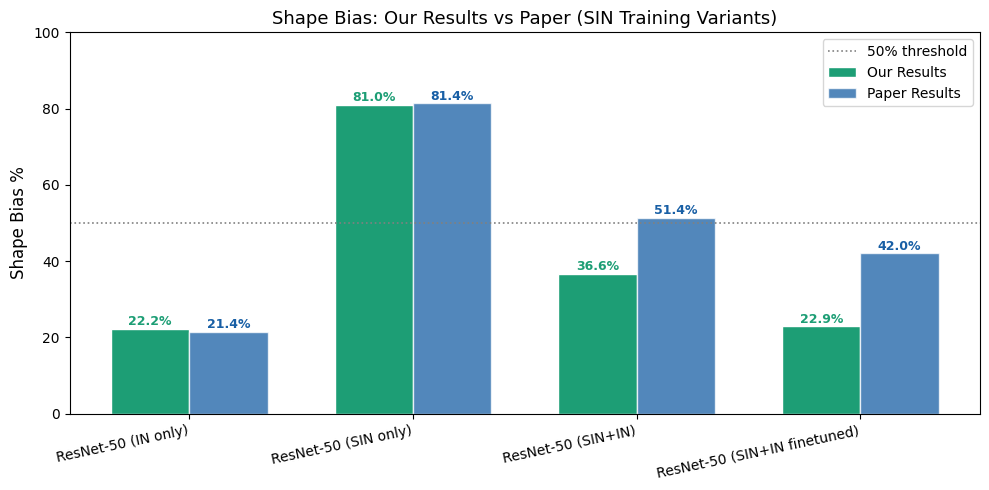

Saved: sin_variants_comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sin_results))
width = 0.35
our_vals   = [sin_results[k]  for k in sin_results]
paper_vals = [paper_sin[k]    for k in sin_results]

b1 = ax.bar(x - width/2, our_vals,   width, label='Our Results',   color='#1D9E75', edgecolor='white')
b2 = ax.bar(x + width/2, paper_vals, width, label='Paper Results', color='#185FA5', edgecolor='white', alpha=0.75)

for bar, val in zip(b1, our_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold', color='#1D9E75')
for bar, val in zip(b2, paper_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold', color='#185FA5')

ax.set_xticks(x)
ax.set_xticklabels(list(sin_results.keys()), rotation=12, ha='right', fontsize=10)
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('Shape Bias: Our Results vs Paper (SIN Training Variants)', fontsize=13)
ax.set_ylim(0, 100)
ax.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% threshold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('sin_variants_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sin_variants_comparison.png')


In [10]:
# Combined summary table for all Phase 3 experiments
print('=' * 65)
print(f'{"EXPERIMENT":<38} {"Shape Bias %":>12} {"vs IN baseline":>13}')
print('=' * 65)
baseline_val = 22.21
all_hp = {}
for r, v in resolution_results.items():
    all_hp[f'Resolution {r}px'] = v
for k, v in augmentation_results.items():
    all_hp[f'Augmentation: {k}'] = v
for k, v in sin_results.items():
    all_hp[k] = v
for name, val in all_hp.items():
    diff = val - baseline_val
    sign = '+' if diff >= 0 else ''
    print(f'{name:<38} {val:>11.2f}% {sign + str(round(diff, 2)):>12}%')
print('=' * 65)


EXPERIMENT                             Shape Bias % vs IN baseline
Resolution 128px                             40.09%       +17.88%
Resolution 192px                             26.86%        +4.65%
Resolution 224px                             22.21%         +0.0%
Resolution 320px                             14.72%        -7.49%
Resolution 384px                             13.48%        -8.73%
Augmentation: Baseline                       22.21%         +0.0%
Augmentation: Horiz Flip                     22.04%        -0.17%
Augmentation: Color Jitter                   29.49%        +7.28%
Augmentation: Grayscale                      37.27%       +15.06%
Augmentation: Random Crop                    19.63%        -2.58%
ResNet-50 (IN only)                          22.21%         +0.0%
ResNet-50 (SIN only)                         81.00%       +58.79%
ResNet-50 (SIN+IN)                           36.65%       +14.44%
ResNet-50 (SIN+IN finetuned)                 22.88%        +0.67%


---
# Phase 4 - Model Evaluation & Error Analysis
## 4A. Per-Category Shape Bias

Breaking down shape bias by object category to find which categories the
model struggles with most (texture-dominated) vs handles well (shape-dominated).

In [11]:
sb_baseline, df_baseline = compute_shape_bias(resnet50, BASE_TRANSFORM)
df_conflict_base = df_baseline[df_baseline['shape'] != df_baseline['texture']].copy()

category_stats = []
for cat in df_conflict_base['shape'].unique():
    cat_df = df_conflict_base[df_conflict_base['shape'] == cat]
    cs = (cat_df['decision'] == cat_df['shape']).sum()
    ct = (cat_df['decision'] == cat_df['texture']).sum()
    total = cs + ct
    sb_cat = round(float(cs / total * 100), 2) if total > 0 else 0.0
    category_stats.append({
        'category':     cat,
        'shape_bias':   sb_cat,
        'shape_wins':   int(cs),
        'texture_wins': int(ct),
        'total':        int(total)
    })

df_cat = pd.DataFrame(category_stats).sort_values('shape_bias', ascending=False)
print('Per-Category Shape Bias (ResNet-50 Standard)\n')
print(df_cat.to_string(index=False))


Per-Category Shape Bias (ResNet-50 Standard)

category  shape_bias  shape_wins  texture_wins  total
   clock       74.07          40            14     54
  bottle       43.94          29            37     66
     car       39.66          23            35     58
   truck       36.51          23            40     63
 bicycle       30.23          13            30     43
    oven       17.39           8            38     46
     cat       16.00           8            42     50
keyboard       15.52           9            49     58
     dog       14.00           7            43     50
    bear       11.63           5            38     43
   chair        8.16           4            45     49
    boat        7.14           3            39     42
elephant        6.52           3            43     46
airplane        4.65           2            41     43
   knife        4.35           2            44     46
    bird        0.00           0            49     49


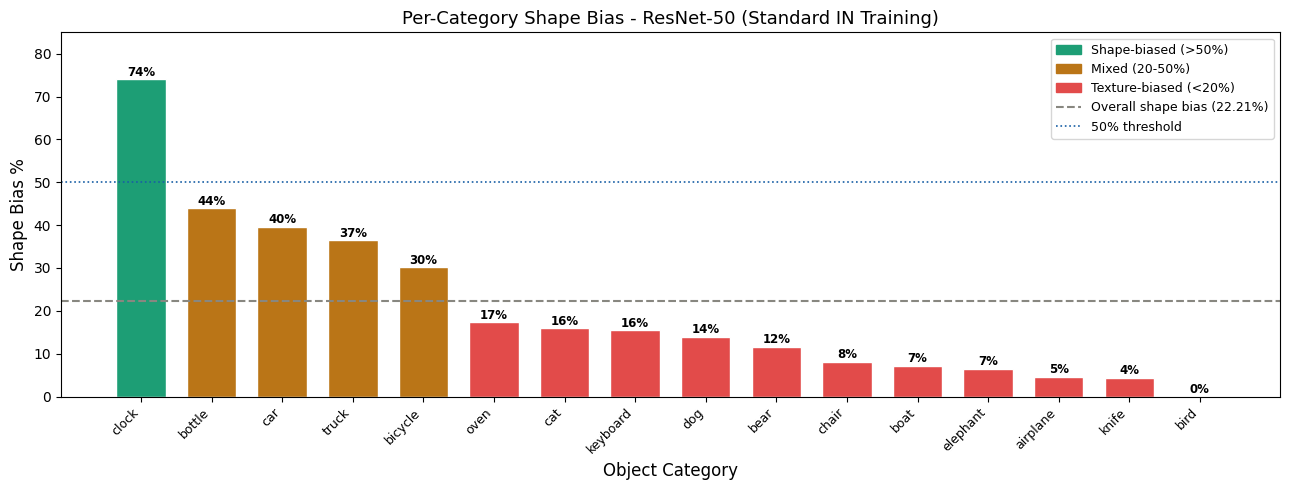

Saved: per_category_shape_bias.png


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#1D9E75' if v > 50 else ('#E24B4A' if v < 20 else '#BA7517')
          for v in df_cat['shape_bias']]
bars = ax.bar(df_cat['category'], df_cat['shape_bias'],
              color=colors, edgecolor='white', width=0.7)
ax.axhline(y=22.21, color='#888780', linestyle='--', linewidth=1.5,
           label='Overall shape bias (22.21%)')
ax.axhline(y=50, color='#185FA5', linestyle=':', linewidth=1.2, label='50% threshold')
for bar, val in zip(bars, df_cat['shape_bias']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.0f}%', ha='center', fontsize=8.5, fontweight='bold')
ax.set_xlabel('Object Category', fontsize=12)
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('Per-Category Shape Bias - ResNet-50 (Standard IN Training)', fontsize=13)
ax.set_xticklabels(df_cat['category'], rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 85)
gp = mpatches.Patch(color='#1D9E75', label='Shape-biased (>50%)')
ap = mpatches.Patch(color='#BA7517', label='Mixed (20-50%)')
rp = mpatches.Patch(color='#E24B4A', label='Texture-biased (<20%)')
ax.legend(handles=[gp, ap, rp] + ax.get_legend_handles_labels()[0], fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('per_category_shape_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_category_shape_bias.png')


## 4B. Top-5 Shape-Biased vs Top-5 Texture-Biased Categories

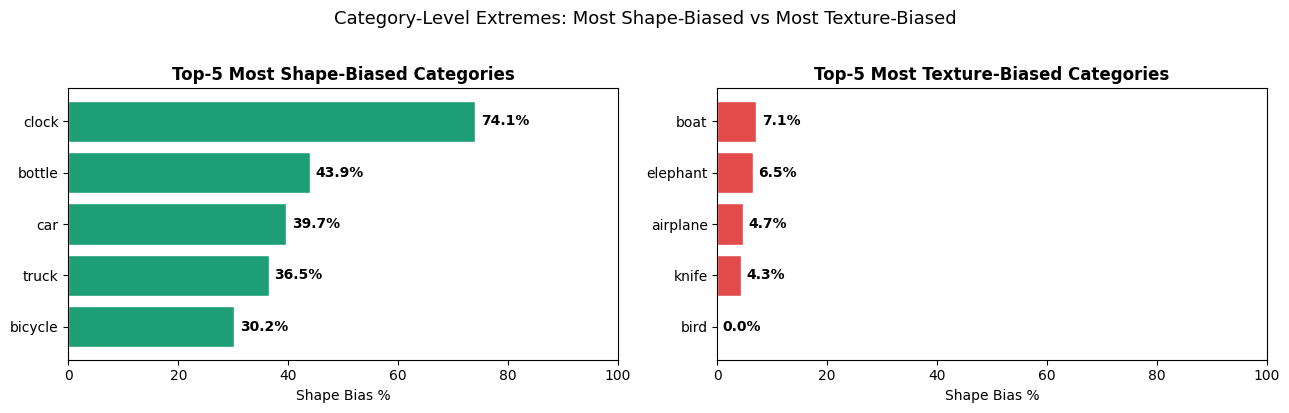

Saved: top5_categories.png


In [13]:
top5_shape   = df_cat.head(5)
top5_texture = df_cat.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(top5_shape['category'].values[::-1], top5_shape['shape_bias'].values[::-1],
             color='#1D9E75', edgecolor='white')
axes[0].set_title('Top-5 Most Shape-Biased Categories', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Shape Bias %')
axes[0].set_xlim(0, 100)
for i, val in enumerate(top5_shape['shape_bias'].values[::-1]):
    axes[0].text(val + 1, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

axes[1].barh(top5_texture['category'].values[::-1], top5_texture['shape_bias'].values[::-1],
             color='#E24B4A', edgecolor='white')
axes[1].set_title('Top-5 Most Texture-Biased Categories', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Shape Bias %')
axes[1].set_xlim(0, 100)
for i, val in enumerate(top5_texture['shape_bias'].values[::-1]):
    axes[1].text(val + 1, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Category-Level Extremes: Most Shape-Biased vs Most Texture-Biased', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('top5_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top5_categories.png')


## 4C. Texture Confusion Heatmap

Shows which texture categories most confuse each shape category.
Cell value = % of times the model chose the texture label over the shape label.

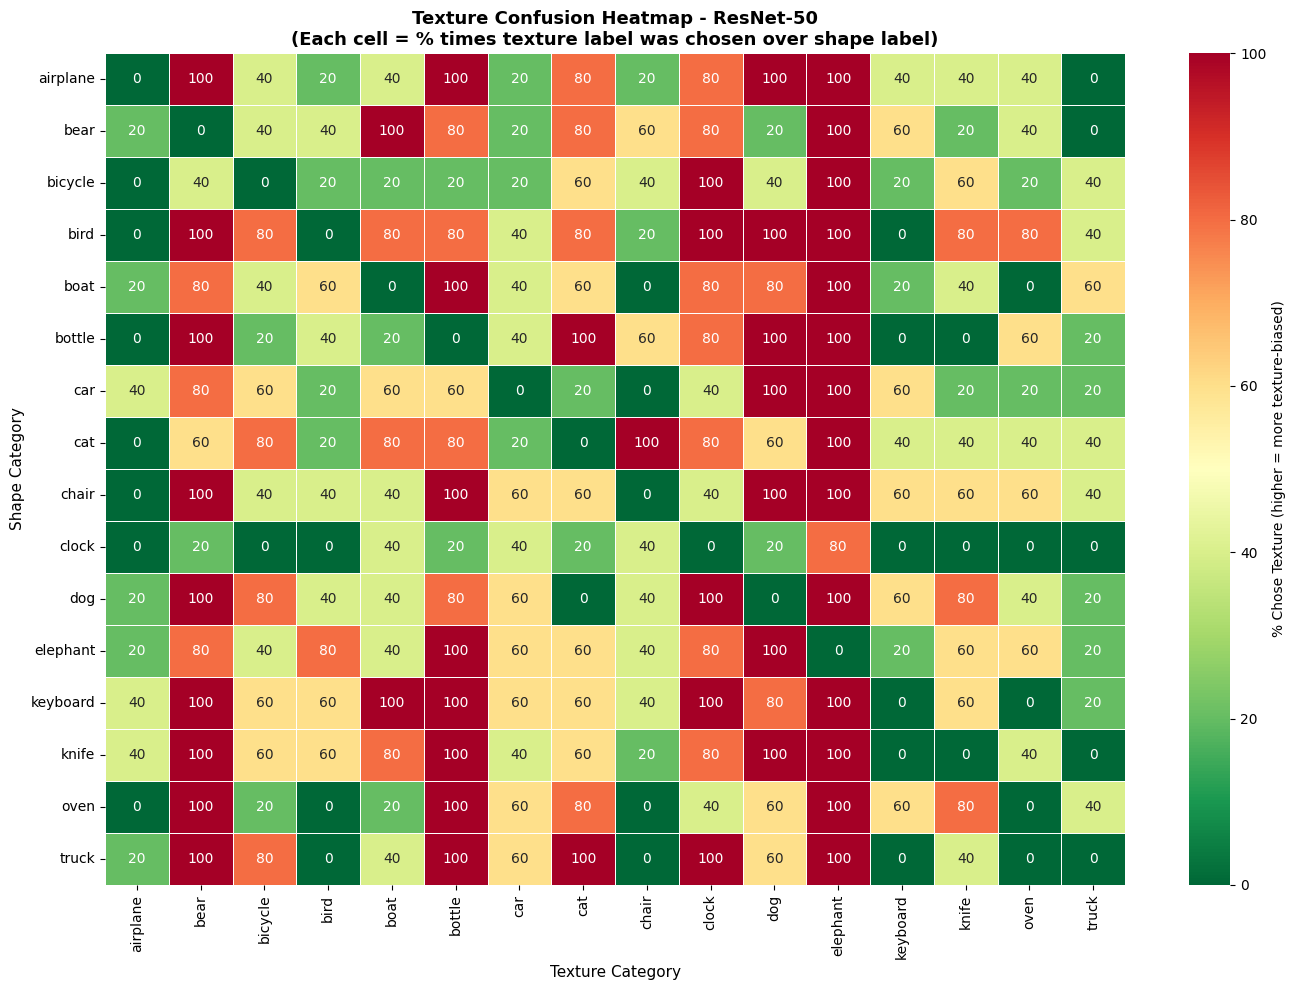

Saved: texture_confusion_heatmap.png


In [14]:
df_c = df_conflict_base.copy()
df_c['chose_texture'] = (df_c['decision'] == df_c['texture']).astype(int)

pivot = df_c.pivot_table(values='chose_texture', index='shape',
                         columns='texture', aggfunc='mean', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot * 100, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': '% Chose Texture (higher = more texture-biased)'})
ax.set_title('Texture Confusion Heatmap - ResNet-50\n'
             '(Each cell = % times texture label was chosen over shape label)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Texture Category', fontsize=11)
ax.set_ylabel('Shape Category', fontsize=11)
plt.tight_layout()
plt.savefig('texture_confusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: texture_confusion_heatmap.png')


## 4D. Cross-Model Category Comparison: IN-only vs SIN-trained

Comparing per-category error patterns between standard ResNet-50 and SIN-trained model_A.
This reveals whether SIN training uniformly improves all categories or helps specific ones more.

In [15]:
sb_sinA, df_sinA = compute_shape_bias(model_A, BASE_TRANSFORM)
df_conflict_sinA = df_sinA[df_sinA['shape'] != df_sinA['texture']].copy()

cat_stats_sinA = []
for cat in df_conflict_sinA['shape'].unique():
    cat_df = df_conflict_sinA[df_conflict_sinA['shape'] == cat]
    cs = (cat_df['decision'] == cat_df['shape']).sum()
    ct = (cat_df['decision'] == cat_df['texture']).sum()
    total = cs + ct
    sb_cat = round(float(cs / total * 100), 2) if total > 0 else 0.0
    cat_stats_sinA.append({'category': cat, 'shape_bias_SIN': sb_cat})

df_cat_sinA = pd.DataFrame(cat_stats_sinA)
df_compare  = df_cat.merge(df_cat_sinA, on='category').sort_values('shape_bias', ascending=True)
df_compare['improvement'] = (df_compare['shape_bias_SIN'] - df_compare['shape_bias']).round(2)

print(f'{"Category":<15} {"IN only":>10} {"SIN only":>10} {"Improvement":>13}')
print('-' * 52)
for _, row in df_compare.iterrows():
    sign = '+' if row['improvement'] >= 0 else ''
    print(f"{row['category']:<15} {row['shape_bias']:>9.1f}% {row['shape_bias_SIN']:>9.1f}%  "
          f"{sign}{row['improvement']:.1f}%")


Category           IN only   SIN only   Improvement
----------------------------------------------------
bird                  0.0%      84.1%  +84.1%
knife                 4.3%      53.9%  +49.5%
airplane              4.7%      48.7%  +44.1%
elephant              6.5%      88.7%  +82.2%
boat                  7.1%      53.9%  +46.7%
chair                 8.2%      90.0%  +81.8%
bear                 11.6%      76.9%  +65.3%
dog                  14.0%      88.4%  +74.4%
keyboard             15.5%      55.6%  +40.0%
cat                  16.0%      84.0%  +68.0%
oven                 17.4%      89.3%  +71.9%
bicycle              30.2%      91.1%  +60.8%
truck                36.5%      90.6%  +54.1%
car                  39.7%      76.9%  +37.3%
bottle               43.9%      82.5%  +38.5%
clock                74.1%      97.0%  +22.9%


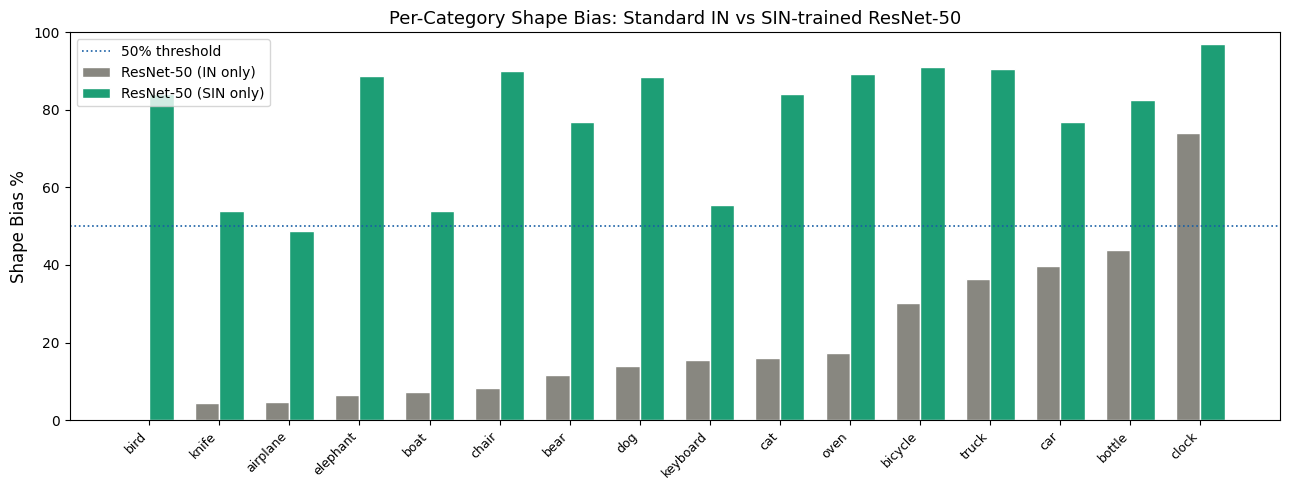

Saved: cross_model_category_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(df_compare))
width = 0.35

b1 = ax.bar(x - width/2, df_compare['shape_bias'],     width,
            label='ResNet-50 (IN only)',   color='#888780', edgecolor='white')
b2 = ax.bar(x + width/2, df_compare['shape_bias_SIN'], width,
            label='ResNet-50 (SIN only)',  color='#1D9E75', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_compare['category'].tolist(), rotation=45, ha='right', fontsize=9)
ax.axhline(50, color='#185FA5', linestyle=':', linewidth=1.2, label='50% threshold')
ax.set_ylabel('Shape Bias %', fontsize=12)
ax.set_title('Per-Category Shape Bias: Standard IN vs SIN-trained ResNet-50', fontsize=13)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('cross_model_category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_model_category_comparison.png')


## 4E. Final Evaluation Metrics Table — All Models

In [17]:
def compute_overall_accuracy(model, transform, stimuli_dir=STIMULI_DIR, device=device):
    """Overall accuracy: does the model correctly classify the shape category?"""
    model.eval().to(device)
    correct = total = 0
    for category in os.listdir(stimuli_dir):
        cat_path = os.path.join(stimuli_dir, category)
        if not os.path.isdir(cat_path):
            continue
        for img_name in os.listdir(cat_path):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img = Image.open(os.path.join(cat_path, img_name)).convert('RGB')
            inp = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                out = model(inp)
            probs    = torch.softmax(out, dim=1).squeeze().cpu().numpy()
            decision = mapping.probabilities_to_decision(probs)
            truth    = re.sub(r'\d+', '', img_name.split('-')[0])
            correct += int(decision == truth)
            total   += 1
    return round(correct / total * 100, 2) if total > 0 else 0.0

eval_models = {
    'ResNet-50 (IN only)':           resnet50,
    'ResNet-50 (SIN only)':          model_A,
    'ResNet-50 (SIN+IN)':            model_B,
    'ResNet-50 (SIN+IN finetuned)':  model_C,
}

final_rows = []
for name, mdl in eval_models.items():
    sb  = sin_results.get(name)
    if sb is None:
        sb, _ = compute_shape_bias(mdl, BASE_TRANSFORM)
    acc  = compute_overall_accuracy(mdl, BASE_TRANSFORM)
    psb  = paper_sin[name]
    diff = round(sb - psb, 2)
    final_rows.append({
        'Model':                  name,
        'Shape Bias % (ours)':    sb,
        'Shape Bias % (paper)':   psb,
        'Diff from paper':        diff,
        'Overall Accuracy %':     acc,
    })
    print(f'{name:<35}: SB={sb:.2f}% (paper {psb:.2f}%, diff {diff:+.2f}%), Acc={acc:.2f}%')

df_eval = pd.DataFrame(final_rows)
print('\n' + '=' * 80)
print(df_eval.to_string(index=False))
print('=' * 80)


ResNet-50 (IN only)                : SB=22.21% (paper 21.39%, diff +0.82%), Acc=19.22%
ResNet-50 (SIN only)               : SB=81.00% (paper 81.37%, diff -0.37%), Acc=52.97%
ResNet-50 (SIN+IN)                 : SB=36.65% (paper 51.39%, diff -14.74%), Acc=28.36%
ResNet-50 (SIN+IN finetuned)       : SB=22.88% (paper 42.04%, diff -19.16%), Acc=19.77%

                       Model  Shape Bias % (ours)  Shape Bias % (paper)  Diff from paper  Overall Accuracy %
         ResNet-50 (IN only)                22.21                 21.39             0.82               19.22
        ResNet-50 (SIN only)                81.00                 81.37            -0.37               52.97
          ResNet-50 (SIN+IN)                36.65                 51.39           -14.74               28.36
ResNet-50 (SIN+IN finetuned)                22.88                 42.04           -19.16               19.77


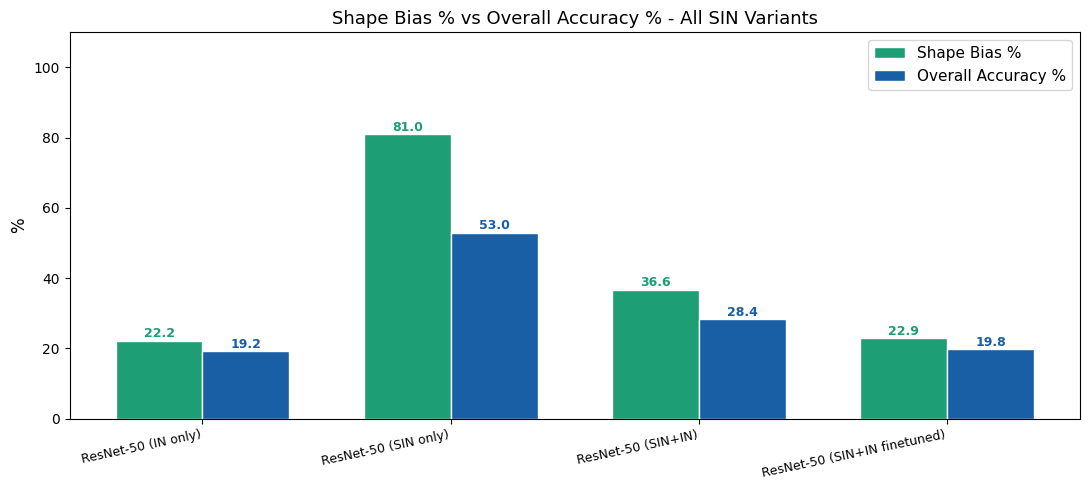

Saved: final_evaluation_table.png


In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_eval))
width = 0.35

b1 = ax.bar(x - width/2, df_eval['Shape Bias % (ours)'],  width,
            label='Shape Bias %',       color='#1D9E75', edgecolor='white')
b2 = ax.bar(x + width/2, df_eval['Overall Accuracy %'], width,
            label='Overall Accuracy %', color='#185FA5', edgecolor='white')

for bar, val in zip(b1, df_eval['Shape Bias % (ours)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=9, color='#1D9E75', fontweight='bold')
for bar, val in zip(b2, df_eval['Overall Accuracy %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=9, color='#185FA5', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_eval['Model'].tolist(), rotation=12, ha='right', fontsize=9)
ax.set_ylabel('%', fontsize=12)
ax.set_title('Shape Bias % vs Overall Accuracy % - All SIN Variants', fontsize=13)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('final_evaluation_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_evaluation_table.png')
